1. Imports


In [110]:
import pandas as pd
import sklearn
import xgboost as xgb
import matplotlib.pyplot as plt


2. Load and Inspect the Data 
This is a basic exploratory step to identify the features in the dataset 


In [111]:
df = pd.read_csv("post natal data.csv")

In [112]:
df.shape          # rows, columns
df.info()         # dtypes, non-null counts
df.head()
df.describe()     # numeric summary stats
df.isnull().sum() # missing values per column
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 11 columns):
 #   Column                                     Non-Null Count  Dtype
---  ------                                     --------------  -----
 0   Timestamp                                  1503 non-null   str  
 1   Age                                        1503 non-null   str  
 2   Feeling sad or Tearful                     1503 non-null   str  
 3   Irritable towards baby & partner           1497 non-null   str  
 4   Trouble sleeping at night                  1503 non-null   str  
 5   Problems concentrating or making decision  1491 non-null   str  
 6   Overeating or loss of appetite             1503 non-null   str  
 7   Feeling anxious                            1503 non-null   str  
 8   Feeling of guilt                           1494 non-null   str  
 9   Problems of bonding with baby              1503 non-null   str  
 10  Suicide attempt                            1503 non-null   

np.int64(1088)

In [113]:
df.head()

,Timestamp,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,6/14/2022 20:04,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
3,6/14/2022 20:05,35-40,Yes,Yes,Yes,Yes,No,Yes,Maybe,No,No
4,6/14/2022 20:06,40-45,Yes,No,Two or more days a week,Yes,No,Yes,No,Yes,No


In [114]:
# Checking the total number of duplicates
df.duplicated().sum()


np.int64(1088)

In [115]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(20)

,Timestamp,Age,Feeling sad or Tearful,Irritable towards baby & partner,Trouble sleeping at night,Problems concentrating or making decision,Overeating or loss of appetite,Feeling anxious,Feeling of guilt,Problems of bonding with baby,Suicide attempt
0,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
264,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
725,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1150,6/14/2022 20:02,35-40,Yes,Yes,Two or more days a week,Yes,Yes,Yes,No,Yes,Yes
1,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
265,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
726,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
1151,6/14/2022 20:03,40-45,Yes,No,No,Yes,Yes,No,Yes,Yes,No
2,6/14/2022 20:04,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No
266,6/14/2022 20:04,35-40,Yes,No,Yes,Yes,Yes,Yes,No,Sometimes,No


Checking for duplicates indicated that there were 1088 duplicates. However closer scrutiny revealed that the "duplicates" were identical entries (possibly). This is because the data is from a survey that was administered in a setting and multiple users could have submitted exact same data at the same time. 

In [116]:
## Checking the shape of the data frame without the duplicates
df.drop_duplicates().shape[0]

415

In [117]:
# Show the categories/ responses in each column of the data frame
for col in df.columns:
    print(col, "->", df[col].unique())
    print()

Timestamp -> <StringArray>
['6/14/2022 20:02', '6/14/2022 20:03', '6/14/2022 20:04', '6/14/2022 20:05',
 '6/14/2022 20:06', '6/14/2022 20:07', '6/14/2022 20:11', '6/14/2022 22:04',
 '6/14/2022 22:05', '6/14/2022 22:06', '6/14/2022 22:07', '6/14/2022 22:08',
 '6/14/2022 22:09', '6/14/2022 22:10', '6/14/2022 22:15', '6/14/2022 22:16',
 '6/14/2022 22:17', '6/14/2022 22:18', '6/14/2022 23:25', '6/14/2022 23:26',
 '6/14/2022 23:27', '6/14/2022 23:28', '6/14/2022 23:29', '6/14/2022 23:30',
 '6/14/2022 23:31', '6/14/2022 23:32', '6/14/2022 23:33', '6/14/2022 23:34',
 '6/14/2022 23:35', '6/14/2022 23:36', '6/14/2022 23:37', '6/14/2022 23:38',
 '6/14/2022 23:39', '6/14/2022 23:40', '6/14/2022 23:41', '6/14/2022 23:42',
 '6/14/2022 23:43', '6/14/2022 23:44', '6/14/2022 23:45', '6/14/2022 23:46',
 '6/14/2022 23:47', '6/14/2022 23:48', '6/14/2022 23:49', '6/14/2022 23:50',
 '6/14/2022 23:52', '6/14/2022 23:53',  '6/15/2022 0:02',  '6/15/2022 0:06',
  '6/15/2022 0:07',  '6/15/2022 0:10',  '6/15/202

In [118]:
# conversion of date column into usable date time format
df["Timestamp"] = pd.to_datetime(df["Timestamp"])

In [119]:
# Sanity check on the age column. 
df["Age"].unique()

<StringArray>
['35-40', '40-45', '30-35', '45-50', '25-30']
Length: 5, dtype: str

In [120]:
df[["Irritable towards baby & partner", 
    "Problems concentrating or making decision", 
    "Feeling of guilt"]].isnull().sum()

Irritable towards baby & partner              6
Problems concentrating or making decision    12
Feeling of guilt                              9
dtype: int64

In [121]:
# Drop the null values in the above columns
# Design decision here is because this is mental health data and it is an ethical concern to impute data into the missing values. 
df = df.dropna(subset=["Irritable towards baby & partner", 
                        "Problems concentrating or making decision", 
                        "Feeling of guilt"])

In [122]:
# Loop through every text column and report how many rows
# have leading/trailing whitespace in each
for col in df.select_dtypes(include="object").columns:
    count = (df[col] != df[col].str.strip()).sum()
    if count > 0:
        print(f"{col}: {count} rows with whitespace issues")

/var/folders/hd/v5xnbq4d7_d6vrkh438_l57c0000gp/T/ipykernel_10247/583479632.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [123]:
# Check what the actual unique ranges are first, so you order them correctly
print(df["Age"].unique())

<StringArray>
['35-40', '40-45', '30-35', '45-50', '25-30']
Length: 5, dtype: str


In [124]:
# Conversion of age values to categorical data
from pandas.api.types import CategoricalDtype

age_order = ["25-30","30-35", "35-40", "40-45", "45-50"]

age_type = CategoricalDtype(categories=age_order, ordered=True)
df["Age"] = df["Age"].astype(age_type)

# Conversion of ordered categorical data to numeric values
df["Age"] = df["Age"].cat.codes

The values in the data currently are largely yes, no, sometimes (or other value) all of which need to be encoded into values that the XG Boost model will be able to compute. 
Two options here are: Label encoding or One hot encoding. 
I have chosen one hot encoding because it prevents mathematical bias according to this paper here: https://pmc.ncbi.nlm.nih.gov/articles/PMC12909650/

In [125]:
for col in df.select_dtypes(include="object").columns:
    print(col, "->", df[col].unique())

Feeling sad or Tearful -> <StringArray>
['Yes', 'No', 'Sometimes']
Length: 3, dtype: str
Irritable towards baby & partner -> <StringArray>
['Yes', 'No', 'Sometimes']
Length: 3, dtype: str
Trouble sleeping at night -> <StringArray>
['Two or more days a week', 'No', 'Yes']
Length: 3, dtype: str
Problems concentrating or making decision -> <StringArray>
['Yes', 'No', 'Often']
Length: 3, dtype: str
Overeating or loss of appetite -> <StringArray>
['Yes', 'No', 'Not at all']
Length: 3, dtype: str
Feeling anxious -> <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Feeling of guilt -> <StringArray>
['No', 'Yes', 'Maybe']
Length: 3, dtype: str
Problems of bonding with baby -> <StringArray>
['Yes', 'Sometimes', 'No']
Length: 3, dtype: str
Suicide attempt -> <StringArray>
['Yes', 'No', 'Not interested to say']
Length: 3, dtype: str


/var/folders/hd/v5xnbq4d7_d6vrkh438_l57c0000gp/T/ipykernel_10247/3838889049.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [126]:
# Feeling anxious has only 2 categories 
df["Feeling anxious"] = df["Feeling anxious"].map({"Yes": 1, "No": 0})

In [127]:
from sklearn.preprocessing import OneHotEncoder

multi_choice_cols = [
    "Feeling sad or Tearful",
    "Irritable towards baby & partner",
    "Trouble sleeping at night",
    "Problems concentrating or making decision",
    "Overeating or loss of appetite",
    "Feeling of guilt",
    "Problems of bonding with baby",
    "Suicide attempt"
]

# Create the encoder 
encoder = OneHotEncoder(sparse_output=False)

# Fit and transform the selected columns
encoded_array = encoder.fit_transform(df[multi_choice_cols])

# Convert the result back into a dataframe with proper column names
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(multi_choice_cols),
    index=df.index
)

# Drop the original text columns and attach the new encoded ones
df = df.drop(columns=multi_choice_cols)
df = pd.concat([df, encoded_df], axis=1)

In [128]:
df.dtypes    
df.shape     
df.head()

,Timestamp,Age,Feeling anxious,Feeling sad or Tearful_No,Feeling sad or Tearful_Sometimes,Feeling sad or Tearful_Yes,Irritable towards baby & partner_No,Irritable towards baby & partner_Sometimes,Irritable towards baby & partner_Yes,Trouble sleeping at night_No,...,Overeating or loss of appetite_Yes,Feeling of guilt_Maybe,Feeling of guilt_No,Feeling of guilt_Yes,Problems of bonding with baby_No,Problems of bonding with baby_Sometimes,Problems of bonding with baby_Yes,Suicide attempt_No,Suicide attempt_Not interested to say,Suicide attempt_Yes
0,2022-06-14 20:02:00,2,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,2022-06-14 20:03:00,3,0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
2,2022-06-14 20:04:00,2,1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3,2022-06-14 20:05:00,2,1,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,2022-06-14 20:06:00,3,1,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [129]:
df.drop(['Timestamp'], axis=1, inplace=True)

In [130]:
df.columns.tolist()

['Age',
 'Feeling anxious',
 'Feeling sad or Tearful_No',
 'Feeling sad or Tearful_Sometimes',
 'Feeling sad or Tearful_Yes',
 'Irritable towards baby & partner_No',
 'Irritable towards baby & partner_Sometimes',
 'Irritable towards baby & partner_Yes',
 'Trouble sleeping at night_No',
 'Trouble sleeping at night_Two or more days a week',
 'Trouble sleeping at night_Yes',
 'Problems concentrating or making decision_No',
 'Problems concentrating or making decision_Often',
 'Problems concentrating or making decision_Yes',
 'Overeating or loss of appetite_No',
 'Overeating or loss of appetite_Not at all',
 'Overeating or loss of appetite_Yes',
 'Feeling of guilt_Maybe',
 'Feeling of guilt_No',
 'Feeling of guilt_Yes',
 'Problems of bonding with baby_No',
 'Problems of bonding with baby_Sometimes',
 'Problems of bonding with baby_Yes',
 'Suicide attempt_No',
 'Suicide attempt_Not interested to say',
 'Suicide attempt_Yes']

At this stage I selected the target variable to be the "Feeling Anxious" column. Original consideration was for the original Suicide attempt question but the data did not have a wide enough variety i.e. it would end up with many yes or many no in either the test or train split meaning the prediction would have a skew. 

3. Creating the train/ test split

In [131]:
y = df["Feeling anxious"]

X = df.drop(columns=["Feeling anxious"])

In [132]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Create a "group" identifier — rows with identical feature values get the same group ID
# This ensures duplicate rows can never be split across train and test
df["_group_id"] = df.drop(columns=["Feeling anxious"]).astype(str).agg("-".join, axis=1)

X = df.drop(columns=["Feeling anxious", "_group_id"])
y = df["Feeling anxious"]
groups = df["_group_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.74      0.77      0.76        91
           1       0.92      0.91      0.91       253

    accuracy                           0.87       344
   macro avg       0.83      0.84      0.83       344
weighted avg       0.87      0.87      0.87       344

[[ 70  21]
 [ 24 229]]
0.9388003301046779


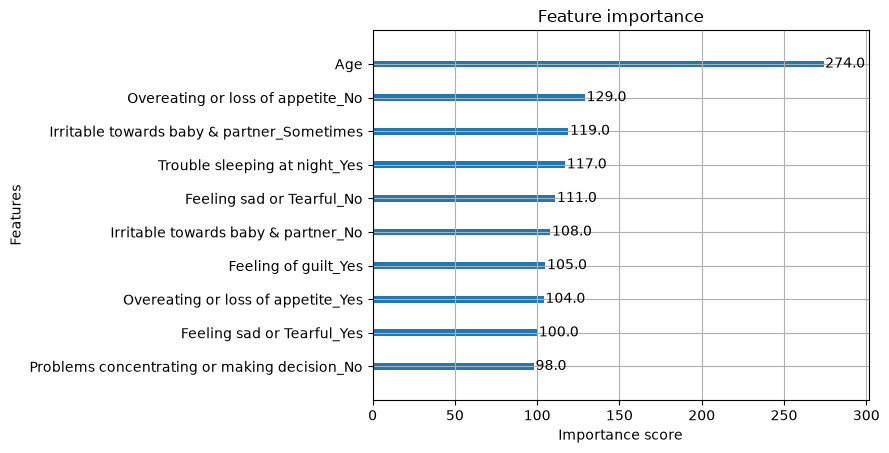

In [133]:
xgb.plot_importance(model, max_num_features=10)
plt.show()

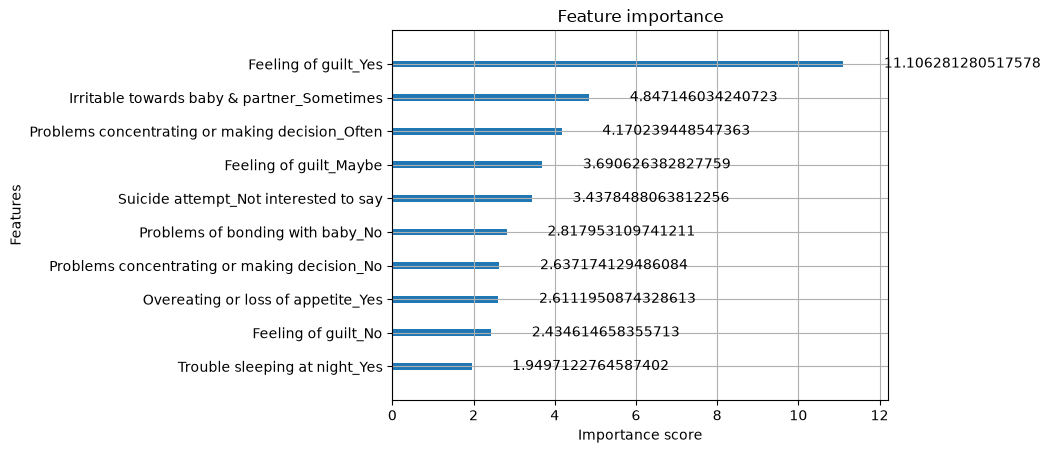

In [134]:
xgb.plot_importance(model, max_num_features=10, importance_type="gain")
plt.show()


In [135]:
from sklearn.model_selection import GroupKFold, cross_val_score

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(model, X, y, cv=gkf, groups=groups, scoring="roc_auc")
print("CV AUC scores:", scores)
print("Mean:", scores.mean(), "Std:", scores.std())

CV AUC scores: [0.82762842 0.91190055 0.94409404 0.84408408 0.87790698]
Mean: 0.8811228130244958 Std: 0.042793699405026836


4. Addition of XAI Layer

In [136]:
import shap

In [137]:
explainer = shap.Explainer(model)

In [138]:
shap_values = explainer.shap_values(X_test)

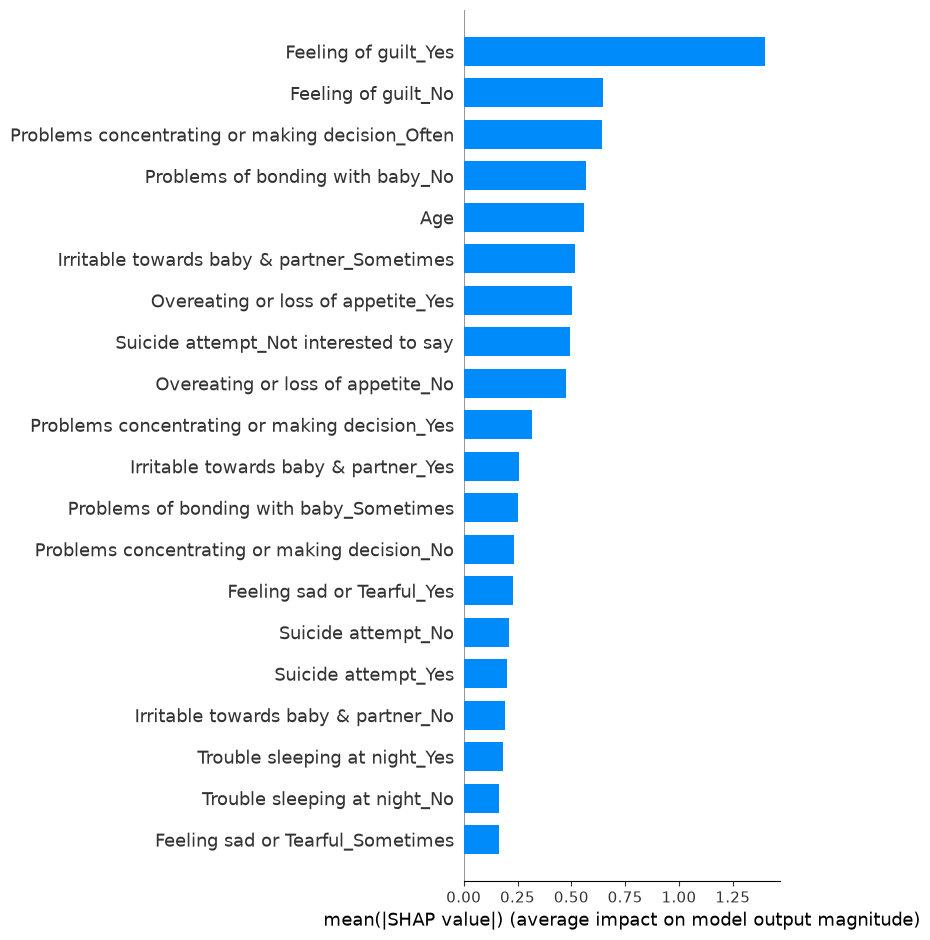

In [139]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

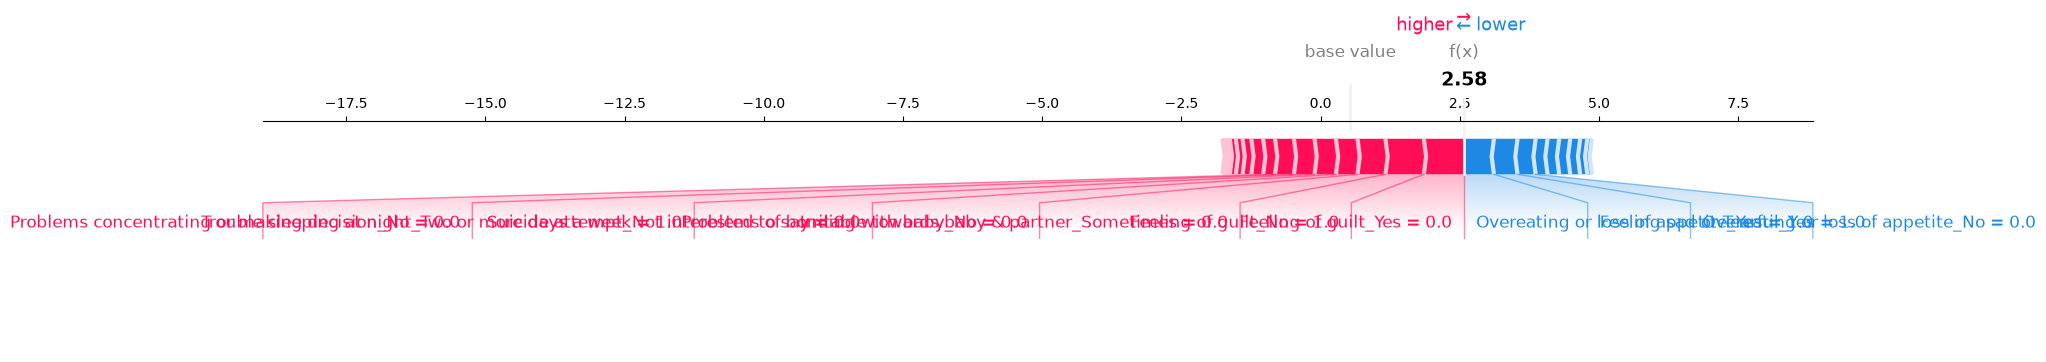

In [140]:
shap.force_plot(
    explainer.expected_value, shap_values[0, :], X_test.iloc[0, :],
    matplotlib=True
)

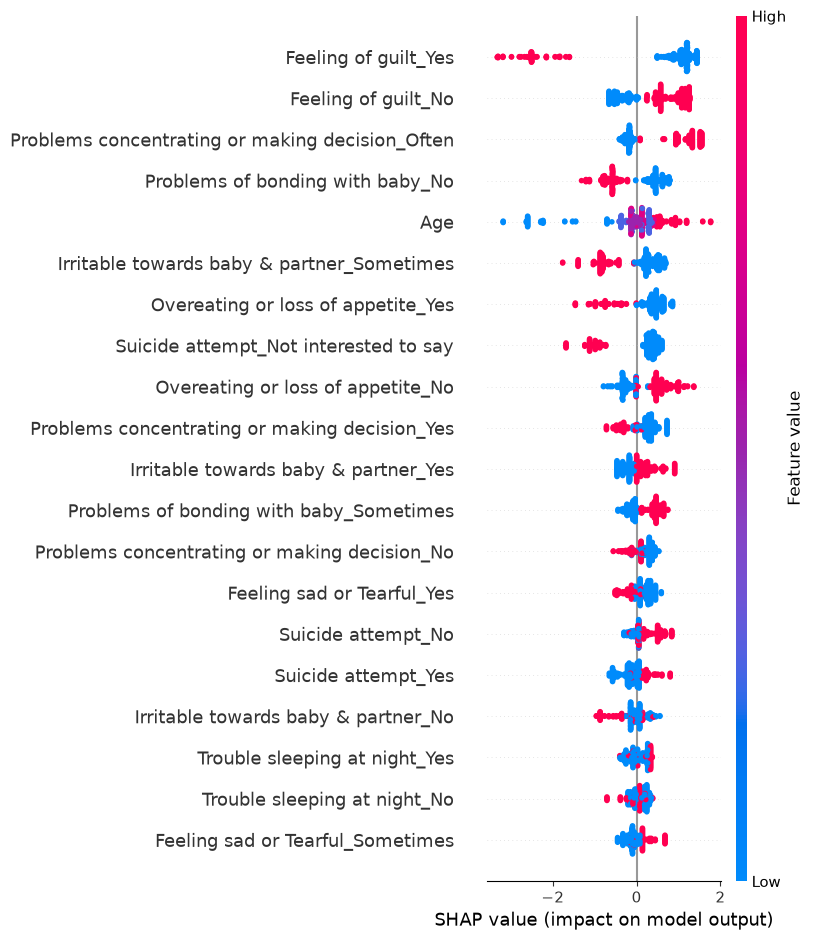

In [141]:
shap.summary_plot(shap_values, X_test)

In [142]:
#from explainerdashboard import ClassifierExplainer, ExplainerDashboard

#xplainer_dash = ClassifierExplainer(model, X_test, y_test)
#ExplainerDashboard(explainer_dash).run()

In [143]:
%whos

Variable                Type                 Data/Info
------------------------------------------------------
CategoricalDtype        type                 <class 'pandas.CategoricalDtype'>
GroupKFold              ABCMeta              <class 'sklearn.model_sel<...>ction._split.GroupKFold'>
GroupShuffleSplit       ABCMeta              <class 'sklearn.model_sel<...>split.GroupShuffleSplit'>
OneHotEncoder           type                 <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
X                       DataFrame            Shape: (1491, 25)
X_test                  DataFrame            Shape: (344, 25)
X_train                 DataFrame            Shape: (1147, 25)
age_order               list                 n=5
age_type                CategoricalDtype     category
classification_report   function             <function classification_report at 0x1181e9900>
col                     str                  Suicide attempt
confusion_matrix        function             <function confusio

In [144]:
print("final_model" in dir())
print("model" in dir())

False
True


In [145]:
import joblib

print(type(encoder))
print(hasattr(encoder, "categories_"))

# Save the trained model
joblib.dump(model, "model.pkl")

# Save the fitted OneHotEncoder (critical — must be the same one used for training)
joblib.dump(encoder, "encoder.pkl")

# Save the exact column order the model expects, so new predictions match exactly
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

# Save the age ordering, so new predictions can be encoded the same way
age_order = ["25-30", "30-35", "35-40", "40-45", "45-50"]
joblib.dump(age_order, "age_order.pkl")

<class 'sklearn.preprocessing._encoders.OneHotEncoder'>
True


['age_order.pkl']